# NUDGE — Comparative / differential attribution

**The same perturbation, two contexts. Which knob moved — threshold, gain, or ceiling?**

A drug-resistant line and a sensitive line. The same knockdown. Bulk / linear
differential expression tells you *the level moved* — it cannot tell you **how the switch
was rewired**. NUDGE can, and it matters clinically:

- a raised **ceiling** (`v_max`) → the switch still works, it just saturates higher →
  **more dose of the *same* drug**;
- a rewired **gain** (`n`) or **threshold** (`K`) → the switch responds *differently* →
  likely a **different drug class**, not just more dose.

NUDGE fits the two contexts **jointly** with a *shared-vs-per-context* parameter structure
and **BIC-selects** which single knob must differ — or **abstains**. And the load-bearing
honesty (`NUDGE-LIM-016`): a **sequencing-depth / batch difference aligned with the context
axis** mimics a ceiling difference, so NUDGE pins depth *per context* and **abstains** on a
ceiling call it can't separate from a batch — it never manufactures a mechanism from an
artifact.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt

from nudge.circuits import ras_switch_1node
from nudge.inference.differential import attribute_differential, simulate_context_pair

# A 1-node self-activation switch (the Ras motif) is the shared topology of both contexts.
CIRC = ras_switch_1node(n=6.0, vmax=2.5, K=1.0, basal=0.2)
S, OBS, N = 25.0, 0.5, 2000
print("shared switch: self-activation  n=6  vmax=2.5  K=1  basal=0.2")

shared switch: self-activation  n=6  vmax=2.5  K=1  basal=0.2


## 1. A raised ceiling — "more of the same drug"

Context A and context B run the *same* perturbation, but context B's switch has a
**raised ceiling** (`v_max ×1.4`) — the drug-resistance story. We draw both contexts (and
each context's own control) from the linear-noise Gaussian mixture, then ask NUDGE which
knob differs. Ground truth: **ceiling**.

In [2]:
a, b = simulate_context_pair(CIRC, mechanism="ceiling", factor=1.4,
                             n_cells=N, scale_a=S, scale_b=S, obs_sd=OBS, seed=1)
res_ceiling = attribute_differential(a, b, CIRC, steps=250, seed=0)
print("CALL:", res_ceiling.call)
print(res_ceiling.reason)
assert res_ceiling.call == "ceiling-diff"   # ground-truth recovery, proven not asserted

CALL: ceiling-diff
ceiling-diff: the target edge's vmax differs between contexts (vmax_A=2.52 vs vmax_B=3.39, log2 ratio +0.43). This model earns its per-context parameter over the shared null (ΔBIC=109.5) and beats the runner-up threshold-diff (ΔBIC=84.3). Actionable read: a raised/lowered ceiling → the SAME intervention at a different dose


## 2. A rewired gain — "a different drug class"

Now context B differs only in its **gain** (`n ÷ 1.8` — a less-cooperative switch).
Ground truth: **gain**. NUDGE must call `gain-diff`, not ceiling — the actionable read is
*a different class of intervention*, not more dose.

In [3]:
a, b = simulate_context_pair(CIRC, mechanism="gain", factor=0.55,
                             n_cells=N, scale_a=S, scale_b=S, obs_sd=OBS, seed=1)
res_gain = attribute_differential(a, b, CIRC, steps=250, seed=0)
print("CALL:", res_gain.call)
print(res_gain.reason)
assert res_gain.call == "gain-diff"
print("\nceiling-diff -> more of the SAME drug ;  gain-diff -> a DIFFERENT class")

CALL: gain-diff
gain-diff: the target edge's n differs between contexts (n_A=13.3 vs n_B=3.29, log2 ratio -2.02). This model earns its per-context parameter over the shared null (ΔBIC=24.7) and beats the runner-up ceiling-diff (ΔBIC=17.3). Actionable read: a rewired gain → likely a DIFFERENT intervention class, not just more dose

ceiling-diff -> more of the SAME drug ;  gain-diff -> a DIFFERENT class


## 3. The BIC model selection, made visible

NUDGE scores four nested models — `shared` (no difference), `ΔK`, `Δn`, `Δv_max` — by
BIC (lower = more parsimonious; a Δ model must *earn* its extra per-context parameter over
the shared null). The winner names the difference. Here are the two fits above, side by
side (ΔBIC vs the best model; the dashed line is the earn margin).

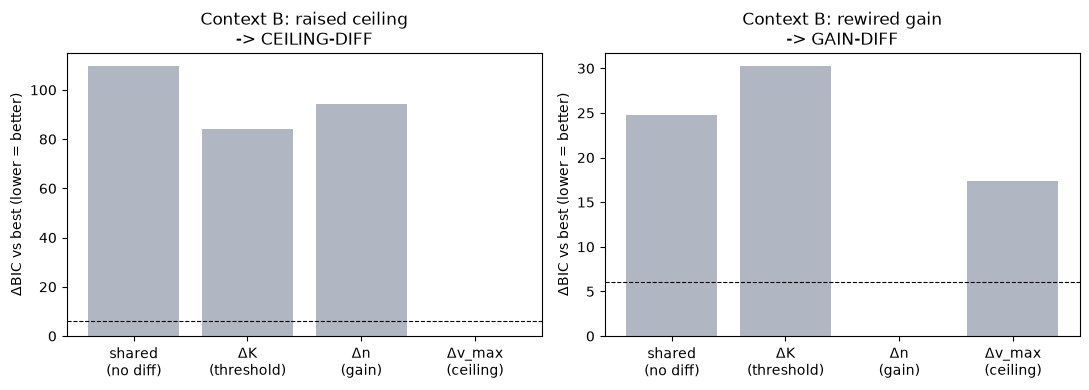

In [4]:
def dbic(fit):
    finite = [v for v in fit.bic.values() if np.isfinite(v)]
    lo = min(finite)
    order = ["shared", "K", "n", "vmax"]
    return [fit.bic[m] - lo if np.isfinite(fit.bic[m]) else np.nan for m in order], order

labels = {"shared": "shared\n(no diff)", "K": "ΔK\n(threshold)",
          "n": "Δn\n(gain)", "vmax": "Δv_max\n(ceiling)"}
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, res, title in [
    (axes[0], res_ceiling, "Context B: raised ceiling"),
    (axes[1], res_gain, "Context B: rewired gain"),
]:
    vals, order = dbic(res.fit)
    colors = ["#4C9F70" if m == res.fit.best_diff and res.fit.selected != "shared"
              else "#B0B7C3" for m in order]
    ax.bar([labels[m] for m in order], vals, color=colors)
    ax.set_title(f"{title}\n-> {res.call.upper()}")
    ax.set_ylabel("ΔBIC vs best (lower = better)")
    ax.axhline(6, ls="--", c="k", lw=0.8)
fig.tight_layout()
plt.show()

## 4. The load-bearing honesty: a depth/batch confound → abstain

The dangerous artifact. Context B has **NO real mechanism difference** — but it was
**sequenced ~1.6× deeper** (its control *and* its perturbed cells), a depth/batch
difference that *aligns with the context axis*. A global depth scale is degenerate with
the ceiling (`scale ⇄ v_max`), so this can **look like a raised ceiling**. A naive tool
would call `ceiling-diff` and send you chasing "more drug" — a confident wrong answer.

NUDGE pins depth **per context** from each control; when the two contexts' depths differ
beyond tolerance — a depth/batch difference aligned with the context axis — it **abstains**
(`NUDGE-LIM-016`), because it cannot certify a masked ceiling isn't hiding in the depth.
(A cleanly-resolved *threshold* or *gain* difference, being orthogonal to a global scale,
would still be callable — only the ceiling channel is confounded.) Ground truth: **no real
mechanism — abstain**.

In [5]:
confident_wrong = 0
for seed in (1, 2, 3):
    a, b = simulate_context_pair(CIRC, mechanism="none",  # NO mechanism difference...
                                 n_cells=N, scale_a=S, scale_b=S * 1.6,  # ...but B ~1.6x deeper
                                 obs_sd=OBS, seed=seed)
    res = attribute_differential(a, b, CIRC, steps=250, seed=0)
    print(f"seed {seed}: CALL = {res.call}   (per-context depth ratio "
          f"{res.fit.depth_ratio:.2f})")
    if res.call in {"threshold-diff", "gain-diff", "ceiling-diff"}:
        confident_wrong += 1
print("\n" + res.reason)
assert confident_wrong == 0
print("\n0 confident-wrong calls on the depth confound -> NUDGE abstained every time")

seed 1: CALL = unresolved   (per-context depth ratio 1.55)


seed 2: CALL = unresolved   (per-context depth ratio 1.64)


seed 3: CALL = unresolved   (per-context depth ratio 1.51)

the two contexts' per-context sequencing depths differ (ratio 1.51 > 1.5) — a depth/batch difference ALIGNED WITH THE CONTEXT AXIS. Depth (global scale) and the ceiling v_max are degenerate, so NUDGE cannot certify that an apparent ceiling / no-clear difference is not a masked depth artifact; it abstains rather than risk a spurious ceiling-diff (NUDGE-LIM-016). Only a cleanly-resolved threshold / gain difference — which reshapes the distribution, orthogonal to a scale — survives a depth difference

0 confident-wrong calls on the depth confound -> NUDGE abstained every time


## What this buys, and where it goes next

A **comparative** mechanism call linear differential expression cannot make: not just
*that* two contexts differ, but *how the switch was rewired* — and therefore whether the
follow-up is **more of the same drug** (a raised ceiling) or **a different class** (a
rewired gain / threshold). And it is **fail-safe**: a depth/batch difference aligned with
the context axis — the most likely way to manufacture a false "ceiling difference" — is
guarded, not called (`NUDGE-LIM-016`); threshold is the hardest to resolve from a bistable
snapshot and honestly abstains (the measured hierarchy gain > ceiling > threshold).

Reproduce from the CLI or the MCP tool (four activity arrays in an `.npz`):

```bash
nudge differential contexts.npz --basal 0.2 --vmax 2.5 --n 6 --k 1
```

```python
# MCP:  differential(path="contexts.npz", basal=0.2, vmax=2.5, n=6.0, k=1.0)
```

See the Mechanism Card `docs/mechanism_cards/differential_attribution.md`
(`NUDGE-METHOD-010`) and `NUDGE-LIM-016` for the full honesty boundary.